In [1]:
import pandas as pd
from datetime import date, timedelta
from fiona.crs import from_epsg
import shapely
import math
import random
import geopandas as gpd
import numpy as np

enc = 'utf-8'
dec = 'greek8'
random.seed(0)

c:\Users\dimit\AppData\Local\Programs\Python\Python39\lib\site-packages\geopandas\_compat.py:112: UserWarning: The Shapely GEOS version (3.10.3-CAPI-1.16.1) is incompatible with the GEOS version PyGEOS was compiled with (3.10.4-CAPI-1.16.2). Conversions between both will be slow.
  warnings.warn(


In [2]:
def create_grid(river_shapes, data_shapes, col_municipal='NAME', col_geometry='geometry', dimension=2):
    """Creates the cell grid for the desired area
    
    Parameters
    --------
    river_shapes : dataframe,
        A GeoDataFrame containing the rivers of the area (to avoid creating cells on them)
                
    data_shapes : dataframe
        A GeoDataFrame containing the polygons (shapes) and the names of municipalities
        
    col_municipal : str, optional
        The column that contains the name for each municipality (default = 'NAME')
        
    col_geometry : string, optional
        The name of the column with the geometry of the river (default = 'geometry')
        
    dimension : int, optional
        The dimension of the square cell in km (eg. 2km x 2km, 1km x 1km) (default = 2)
        
    Returns
    ----------
    cell_df: dataframe
        A dataframe containing the generated cells for each municipality and the centers of each cell
    
    """
    river_shapes_list =  river_shapes[col_geometry].geometry.explode().tolist()
    # Convert cell height dimension to km
    cell_height = (dimension / 6378) * (180 / math.pi)
    
    grid_cells = []
    grid_cells2 = []
    municipal = []
    centers = []
    # Iterate over municipalities to create a grid for each one
    for i in range(data_shapes.shape[0]):
        area_cells = []
        center = []
        # Keep the geometry of municipality
        g_country = data_shapes[col_geometry][i]
        # Extract the bounds of municipality
        xmin, ymin, xmax, ymax = data_shapes[col_geometry][i:i+1].total_bounds
        # Convert cell width dimension to km (dependent to y)
        cell_width  = (dimension / 6378) * (180 / math.pi) / math.cos(ymin  * math.pi/180)
    
        # Iterate to municipality bounds to create the grid's cells
        for x0 in np.arange(xmin, xmax+cell_width, cell_width ):
            for y0 in np.arange(ymin, ymax+cell_height, cell_height):
                y1 = y0+cell_height
                x1 = x0+cell_width
                new_cell = shapely.geometry.box(x0, y0, x1, y1)
                # Check if new cell intersects the municipality
                if new_cell.covered_by(g_country):
                    # Check if new cell intersects previously generated cells
                    delete_cell_boundary = [True for cell in grid_cells2 if new_cell.intersects(cell)]
                    # Check if new cell intersects with rivers
                    delete_cell_river = [True for cell in river_shapes_list if new_cell.intersects(cell)]
                    # Save new cell if it doesn't intersects rivers or previous cells 
                    if not delete_cell_boundary and not delete_cell_river:
                        center.append(new_cell.centroid)
                        area_cells.append(new_cell)
                else:
                    # Continue to next cell generation
                    pass
        # Save the final cells for each municipality
        grid_cells.append(area_cells)
        # Save center of each cell
        centers.append(center)
        # Save municipality name for each generated cell
        municipal.append([data_shapes[col_municipal][i]]*len(area_cells))
        # Save the previous generated cells for intersection check
        grid_cells2 = []
        grid_cells2 = [item for sublist in grid_cells for item in sublist]

    # Flatten lists
    grid_cells_list = [item for sublist in grid_cells for item in sublist]
    centers_list = [item for sublist in centers for item in sublist]
    municipal_list = [item for sublist in municipal for item in sublist]
    
    # Create final GeoDataFrame with municipalities and their cells
    cell_df = gpd.GeoDataFrame(grid_cells_list, columns=[col_geometry], crs=from_epsg(4326))
    cell_df['centers'] = centers_list
    cell_df['NAME'] = municipal_list
    
    x = []
    y = []
    # Extract coordinates from centers
    for index,row in cell_df.iterrows():
        x.append(round(row['centers'].x,5))
        y.append(round(row['centers'].y,5))  
        
    cell_df['x'] = x
    cell_df['y'] = y
    
    return cell_df

def read_river_shapes(col_id, path_rivers, col_geometry='geometry', filter=False, num_region=0, path_region='', *args):
    """Reads rivers shapefile and returns a geopandas dataframe
    
    Parameters
    --------
    col_id : string,
        The name of the column with the id of the river
                
    path_rivers : string
        Path to shapefile of rivers
        
    col_geometry : string, optional
        The name of the column with the geometry of the river (default = 'geometry')
        
    filter : boolean, optional
        If false all rivers will be return (default = False)
        
    num_region : int,optional
        The number of the row of the desired region in GeoDataFrame (default = 0)
        
    path_region : string, optional
        Path to shapefile of region that its' rivers will be kept
        
    data_shapes : dataframe, optional (pass with *args)
        A GeoDataFrame containing the polygons (shapes) and the names of municipalities

    Returns
    ----------
    data: dataframe
        A dataframe containing the desired river shapes
    
    """
    try:
        # reading as shp file
        river_shapes = gpd.read_file(path_rivers, encoding="utf_8")
    except: 
        raise NotImplementedError("Sorry, give me a .shp file.")
    if filter:
        indexes = []
        if path_region:
            try:
                # reading as shp file
                region = gpd.read_file(path_region, encoding="utf_8")
            except: 
                raise NotImplementedError("Sorry, give me a .shp file.")
            for index, row in river_shapes.iterrows():
                if row[col_geometry].intersects(region[col_geometry][num_region]):
                    indexes.append(index)
        else:
            data_shapes=args[0]
            for index, row in river_shapes.iterrows():
                for index2, row2 in data_shapes.iterrows():
                    if row[col_geometry].intersects(row2[col_geometry]):
                        indexes.append(index)
                
        river_shapes = river_shapes.loc[indexes].reset_index(drop=True)
    river_shapes = river_shapes[[col_id, col_geometry]]
    return river_shapes

def process_greek(frame, column):
    frame[column] = frame[column].apply(lambda x : x.strip())
    frame[column] = frame[column].apply(lambda x : x.lower())
    frame[column] = frame[column].apply(lambda x : x.replace('ά','α'))
    frame[column] = frame[column].apply(lambda x : x.replace('έ','ε'))
    frame[column] = frame[column].apply(lambda x : x.replace('ή','η'))
    frame[column] = frame[column].apply(lambda x : x.replace('ί','ι'))
    frame[column] = frame[column].apply(lambda x : x.replace('ύ','υ'))
    frame[column] = frame[column].apply(lambda x : x.replace('ό','ο'))
    frame[column] = frame[column].apply(lambda x : x.replace('ώ','ω'))

In [3]:
## Reading shapefiles from Greece
folder_path = "C:/Users/dimit/Documents/noa hoard/Greece Shapefiles"


greece_gdf = gpd.read_file(f"{folder_path}/elladitsa.shp",  encoding=enc)
greece_regions_gdf = gpd.read_file(f"{folder_path}/perifereies2.shp",  encoding=enc)
rivers_gdf = gpd.read_file(f"{folder_path}/potamoi2.shp", encoding=enc)

In [4]:
greece_gdf.head(5)

,NAME,KWD_YPES,geometry
0,Αμυνταίου,9070,"POLYGON ((21.70746 40.85172, 21.70955 40.85119..."
1,Άθως,None,"MULTIPOLYGON (((24.25167 40.30363, 24.25149 40..."
2,Άκτιου - Βόνιτσας,9124,"MULTIPOLYGON (((20.79456 38.75371, 20.79456 38..."
3,Άνδρου,9268,"MULTIPOLYGON (((24.95917 37.69039, 24.95897 37..."
4,Άργους - Μυκηνών,9233,"POLYGON ((22.52084 37.83857, 22.52111 37.83829..."


In [5]:
greece_regions_gdf.head()

,PER,geometry
0,Π. ΑΝΑΤΟΛΙΚΗΣ ΜΑΚΕΔΟΝΙΑΣ - ΘΡΑΚΗΣ,"MULTIPOLYGON (((23.62358 41.35455, 23.62361 41..."
1,Π. ΚΕΝΤΡΙΚΗΣ ΜΑΚΕΔΟΝΙΑΣ,"MULTIPOLYGON (((21.70423 40.86339, 21.70425 40..."
2,Π. ΔΥΤΙΚΗΣ ΜΑΚΕΔΟΝΙΑΣ,"POLYGON ((20.77648 40.35294, 20.77652 40.35548..."
3,Π. ΗΠΕΙΡΟΥ,"MULTIPOLYGON (((20.00882 39.69130, 20.00884 39..."
4,Π. ΘΕΣΣΑΛΙΑΣ,"MULTIPOLYGON (((21.12042 39.67888, 21.12044 39..."


In [6]:
attica_region_gdf = greece_regions_gdf.loc[greece_regions_gdf['PER'] == 'Π. ΑΤΤΙΚΗΣ']
attica_region_gdf.head()

,PER,geometry
12,Π. ΑΤΤΙΚΗΣ,"MULTIPOLYGON (((22.89876 36.19485, 22.89888 36..."


In [7]:
indexes = []

region = attica_region_gdf

for index, row in greece_gdf.iterrows():
    for index2, row2 in region.iterrows():
                    
        if row['geometry'].intersects(row2['geometry']):
                indexes.append(index)

attica_gdf = greece_gdf.loc[indexes].reset_index(drop=True)

In [8]:
attica_gdf.head()

,NAME,KWD_YPES,geometry
0,Ιλίου,9182,"POLYGON ((23.68392 38.06429, 23.68763 38.06131..."
1,Ύδρας,9214,"MULTIPOLYGON (((23.40645 37.29497, 23.40642 37..."
2,Αίγινας,9208,"MULTIPOLYGON (((23.31935 37.80028, 23.31914 37..."
3,Αγίας Βαρβάρας,9179,"POLYGON ((23.64394 37.99855, 23.64396 37.99856..."
4,Αγίας Παρασκευής,9167,"POLYGON ((23.84009 38.02410, 23.84021 38.02408..."


<AxesSubplot:>

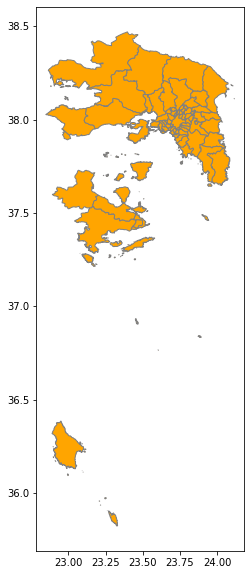

In [9]:
attica_gdf.plot(facecolor="none", edgecolor='grey', figsize=(15, 10), color='orange')

In [10]:
wrong_list = ['Τανάγρας' ,'Θηβαίων', 'Λουτρακίου - Αγ. Θεοδώρων', 'Ερμιονίδας', 'Επιδαύρου']

attica_gdf = attica_gdf[~attica_gdf['NAME'].isin(wrong_list)].copy()

In [11]:
attica_gdf.head(5)

,NAME,KWD_YPES,geometry
0,Ιλίου,9182,"POLYGON ((23.68392 38.06429, 23.68763 38.06131..."
1,Ύδρας,9214,"MULTIPOLYGON (((23.40645 37.29497, 23.40642 37..."
2,Αίγινας,9208,"MULTIPOLYGON (((23.31935 37.80028, 23.31914 37..."
3,Αγίας Βαρβάρας,9179,"POLYGON ((23.64394 37.99855, 23.64396 37.99856..."
4,Αγίας Παρασκευής,9167,"POLYGON ((23.84009 38.02410, 23.84021 38.02408..."


In [12]:
attica_gdf.drop(columns=['KWD_YPES'], inplace = True)
attica_gdf.rename(columns={"NAME": "lau1"}, inplace = True)
process_greek(attica_gdf, 'lau1')

In [13]:
attica_gdf.head(5)

,lau1,geometry
0,ιλιου,"POLYGON ((23.68392 38.06429, 23.68763 38.06131..."
1,υδρας,"MULTIPOLYGON (((23.40645 37.29497, 23.40642 37..."
2,αιγινας,"MULTIPOLYGON (((23.31935 37.80028, 23.31914 37..."
3,αγιας βαρβαρας,"POLYGON ((23.64394 37.99855, 23.64396 37.99856..."
4,αγιας παρασκευης,"POLYGON ((23.84009 38.02410, 23.84021 38.02408..."


<AxesSubplot:>

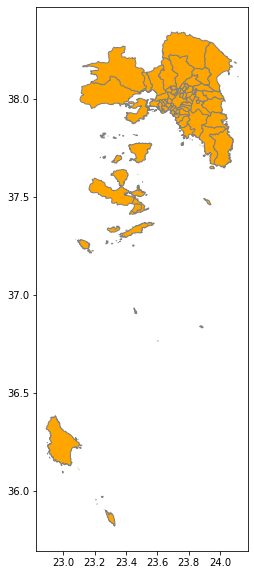

In [14]:
attica_gdf.plot(facecolor="none", edgecolor='grey', figsize=(15, 10), color='orange')

In [15]:
indexes = []

region = attica_region_gdf

for index, row in rivers_gdf.iterrows():
    for index2, row2 in region.iterrows():
                    
        if row['geometry'].intersects(row2['geometry']):
                indexes.append(index)

attica_rivers_gdf = rivers_gdf.loc[indexes].reset_index(drop=True)

In [16]:
attica_rivers_gdf.head()

,objectid,eu_cd,name,altname1,altname2,altname3,region_cd,system,ins_when,ins_by,...,acid_neut,substratum,chloride,a_temp_rge,av_a_temp,ppt,dist_sourc,cont,shape_Leng,geometry
0,9,None,Unknown,Unknown,None,None,None,None,None,None,...,None,None,None,None,0.0,0.0,0.0,no,2499.061150,"LINESTRING (24.02301 38.15953, 24.02301 38.159..."
1,12,None,Unknown,Unknown,None,None,None,None,None,None,...,None,None,None,None,0.0,0.0,0.0,no,3917.094155,"LINESTRING (23.82103 38.07738, 23.81889 38.077..."
2,25,None,ÊÑÕÖÔÇ Ñ.,KRYFTH R.,None,None,None,None,None,None,...,None,None,None,None,0.0,0.0,0.0,no,4186.529821,"LINESTRING (23.31597 38.08893, 23.31597 38.088..."
3,38,None,Unknown,Unknown,None,None,None,None,None,None,...,None,None,None,None,0.0,0.0,0.0,no,1069.313080,"LINESTRING (23.70861 37.92394, 23.70805 37.923..."
4,48,None,Unknown,Unknown,None,None,None,None,None,None,...,None,None,None,None,0.0,0.0,0.0,no,3884.708691,"LINESTRING (23.48943 38.04971, 23.49014 38.050..."


<AxesSubplot:>

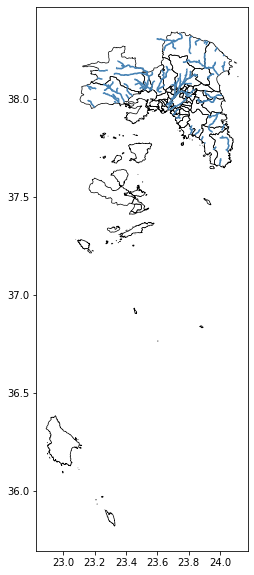

In [17]:
ax = attica_rivers_gdf.plot(markersize=.1, figsize=(10, 10), cmap='jet', color='steelblue')
attica_gdf.plot(facecolor="none", edgecolor='black', ax=ax, lw=0.7)

In [18]:
attica_lau1 = attica_gdf['lau1'].unique().tolist()

with open('data/GR_SHP_Attica_lau1_processed.txt', 'w', encoding=enc) as f:
    for item in attica_lau1:
        f.write("%s\n" % item)

print(f"Number of LAU1 Units in Attica (from shapefile): {len(attica_lau1)}")

Number of LAU1 Units in Attica (from shapefile): 66


In [19]:
attica_gdf.reset_index(inplace=True, drop = True)
attica_rivers_gdf.reset_index(inplace=True, drop=True)

In [20]:
df_grid = create_grid(attica_rivers_gdf, attica_gdf, col_municipal='lau1', dimension=2)
# df_grid_2.to_csv('data/grid_2.csv', index=False)
# # df_grid_2 = pd.read_csv('data/grid_2.csv')
# # df_grid_2['geometry'] = gpd.GeoSeries.from_wkt(df_grid_2['geometry'])
# # df_grid_2 = gpd.GeoDataFrame(df_grid_2, geometry='geometry')

C:\Users\dimit\AppData\Local\Temp/ipykernel_23752/2153756921.py:27: FutureWarning: Currently, index_parts defaults to True, but in the future, it will default to False to be consistent with Pandas. Use `index_parts=True` to keep the current behavior and True/False to silence the warning.
  river_shapes_list =  river_shapes[col_geometry].geometry.explode().tolist()
c:\Users\dimit\AppData\Local\Programs\Python\Python39\lib\site-packages\pyproj\crs\crs.py:141: FutureWarning: '+init=<authority>:<code>' syntax is deprecated. '<authority>:<code>' is the preferred initialization method. When making the change, be mindful of axis order changes: https://pyproj4.github.io/pyproj/stable/gotchas.html#axis-order-changes-in-proj-6
  in_crs_string = _prepare_from_proj_string(in_crs_string)
c:\Users\dimit\AppData\Local\Programs\Python\Python39\lib\site-packages\pandas\core\dtypes\cast.py:118: ShapelyDeprecationWarning: The array interface is deprecated and will no longer work in Shapely 2.0. Convert t

In [21]:
df_grid.rename(columns={"NAME": "lau1"}, inplace = True)

<AxesSubplot:>

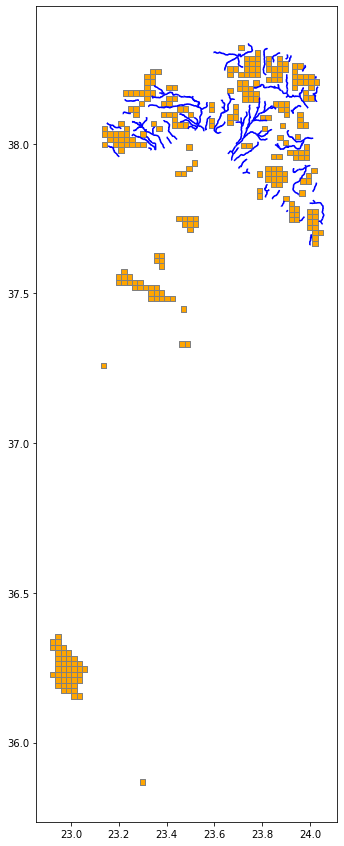

In [22]:
ax = attica_rivers_gdf.plot(markersize=.1, figsize=(15, 15), cmap='jet', color='blue')
df_grid.plot(facecolor="none", edgecolor='grey', ax=ax, color='orange')

In [23]:
grid_lau1 = df_grid['lau1'].unique().tolist()
print(f"Number of LAU1 Units in Grid: {len(grid_lau1)}")

Number of LAU1 Units in Grid: 28


['ιλιου', 'αγιας βαρβαρας', 'αγιας παρασκευης', 'αγιου δημητριου', 'αγιων αναργυρων - καματερου', 'αγκιστριου', 'αιγαλεω', 'αλιμου', 'βριλησσιων', 'βυρωνος', 'γαλατσιου', 'δαφνης - υμηττου', 'ελευσινας', 'ελληνικου - αργυρουπολης', 'ζωγραφου', 'ηλιουπολης', 'ηρακλειου', 'καισαριανης', 'καλλιθεας', 'κερατσινιου - δραπετσωνας', 'κορυδαλλου', 'λυκοβρυσης - πευκης', 'μεταμορφωσεως', 'μοσχατου - ταυρου', 'νεας ιωνιας', 'νεας σμυρνης', 'νικαιας - αγιου ι. ρεντη', 'παλαιου φαληρου', 'παπαγου - χολαργου', 'πειραιως', 'περαματος', 'περιστεριου', 'πετρουπολης', 'πορου', 'φιλαδελφειας - χαλκηδονος', 'φιλοθεης - ψυχικου', 'χαϊδαριου', 'χαλανδριου']


C:\Users\dimit\AppData\Local\Temp/ipykernel_23752/2229233094.py:6: UserWarning: Geometry is in a geographic CRS. Results from 'centroid' are likely incorrect. Use 'GeoSeries.to_crs()' to re-project geometries to a projected CRS before this operation.

  lost_lau1["centroid"] = lost_lau1["geometry"].centroid
c:\Users\dimit\AppData\Local\Programs\Python\Python39\lib\site-packages\geopandas\geodataframe.py:1472: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  super().__setitem__(key, value)


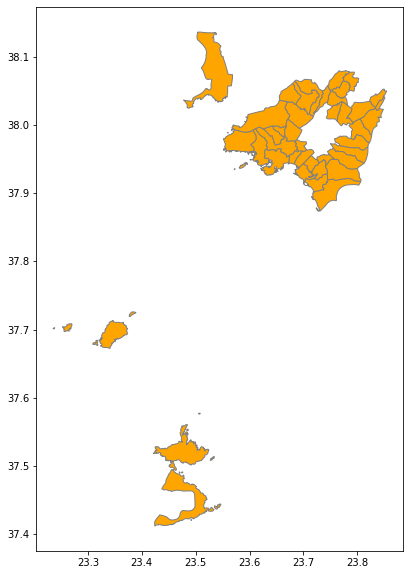

In [24]:
if (len(attica_lau1) != len(grid_lau1)):
    delta = [item for item in attica_lau1 if item not in grid_lau1]
    print(delta)

    lost_lau1 = attica_gdf[attica_gdf['lau1'].isin(delta)]
    lost_lau1["centroid"] = lost_lau1["geometry"].centroid

    add_to_attica_grid = pd.DataFrame()
    add_to_attica_grid['lau1'] = lost_lau1['lau1']
    add_to_attica_grid['geometry'] = lost_lau1['geometry']
    add_to_attica_grid['x'] = round(lost_lau1['centroid'].x, 5)
    add_to_attica_grid['y'] = round(lost_lau1['centroid'].y, 5)

    lost_lau1.plot(facecolor="none", edgecolor='grey', figsize=(10, 10), color='orange')

In [25]:
attica_grid = df_grid.drop(columns=['centers'])

In [26]:
attica_grid

,geometry,lau1,x,y
0,"POLYGON ((23.47525 37.32210, 23.47525 37.34006...",υδρας,23.46396,37.33108
1,"POLYGON ((23.49782 37.32210, 23.49782 37.34006...",υδρας,23.48654,37.33108
2,"POLYGON ((23.46320 37.74067, 23.46320 37.75864...",αιγινας,23.45186,37.74966
3,"POLYGON ((23.48588 37.72271, 23.48588 37.74067...",αιγινας,23.47454,37.73169
4,"POLYGON ((23.48588 37.74067, 23.48588 37.75864...",αιγινας,23.47454,37.74966
...,...,...,...,...
283,"POLYGON ((23.88345 38.24046, 23.88345 38.25843...",ωρωπου,23.87203,38.24944
284,"POLYGON ((23.88345 38.25843, 23.88345 38.27639...",ωρωπου,23.87203,38.26741
285,"POLYGON ((23.88345 38.27639, 23.88345 38.29436...",ωρωπου,23.87203,38.28538
286,"POLYGON ((23.90630 38.24046, 23.90630 38.25843...",ωρωπου,23.89487,38.24944


In [27]:
if (len(attica_lau1) != len(grid_lau1)):
    attica_grid = pd.concat([attica_grid, add_to_attica_grid], axis=0)

attica_grid.reset_index(inplace=True, drop=True)

In [28]:
attica_grid['nuts3'] = 'αττικης'

In [29]:
attica_grid.rename(columns={"geometry": "shape"}, inplace=True)

In [30]:
attica_grid

,shape,lau1,x,y,nuts3
0,"POLYGON ((23.47525 37.32210, 23.47525 37.34006...",υδρας,23.46396,37.33108,αττικης
1,"POLYGON ((23.49782 37.32210, 23.49782 37.34006...",υδρας,23.48654,37.33108,αττικης
2,"POLYGON ((23.46320 37.74067, 23.46320 37.75864...",αιγινας,23.45186,37.74966,αττικης
3,"POLYGON ((23.48588 37.72271, 23.48588 37.74067...",αιγινας,23.47454,37.73169,αττικης
4,"POLYGON ((23.48588 37.74067, 23.48588 37.75864...",αιγινας,23.47454,37.74966,αττικης
...,...,...,...,...,...
321,"MULTIPOLYGON (((23.46992 37.48999, 23.46989 37...",πορου,23.47721,37.48420,αττικης
322,"POLYGON ((23.72177 38.01826, 23.71958 38.01599...",φιλαδελφειας - χαλκηδονος,23.73834,38.03938,αττικης
323,"POLYGON ((23.78121 38.00972, 23.78145 38.00970...",φιλοθεης - ψυχικου,23.77628,38.01477,αττικης
324,"POLYGON ((23.65604 38.03663, 23.65608 38.03649...",χαϊδαριου,23.63084,38.00942,αττικης


In [31]:
attica_grid_points = gpd.GeoDataFrame(attica_grid, geometry=gpd.points_from_xy(attica_grid.x, attica_grid.y))

In [32]:
attica_grid_points

,shape,lau1,x,y,nuts3,geometry
0,"POLYGON ((23.47525 37.32210, 23.47525 37.34006...",υδρας,23.46396,37.33108,αττικης,POINT (23.46396 37.33108)
1,"POLYGON ((23.49782 37.32210, 23.49782 37.34006...",υδρας,23.48654,37.33108,αττικης,POINT (23.48654 37.33108)
2,"POLYGON ((23.46320 37.74067, 23.46320 37.75864...",αιγινας,23.45186,37.74966,αττικης,POINT (23.45186 37.74966)
3,"POLYGON ((23.48588 37.72271, 23.48588 37.74067...",αιγινας,23.47454,37.73169,αττικης,POINT (23.47454 37.73169)
4,"POLYGON ((23.48588 37.74067, 23.48588 37.75864...",αιγινας,23.47454,37.74966,αττικης,POINT (23.47454 37.74966)
...,...,...,...,...,...,...
321,"MULTIPOLYGON (((23.46992 37.48999, 23.46989 37...",πορου,23.47721,37.48420,αττικης,POINT (23.47721 37.48420)
322,"POLYGON ((23.72177 38.01826, 23.71958 38.01599...",φιλαδελφειας - χαλκηδονος,23.73834,38.03938,αττικης,POINT (23.73834 38.03938)
323,"POLYGON ((23.78121 38.00972, 23.78145 38.00970...",φιλοθεης - ψυχικου,23.77628,38.01477,αττικης,POINT (23.77628 38.01477)
324,"POLYGON ((23.65604 38.03663, 23.65608 38.03649...",χαϊδαριου,23.63084,38.00942,αττικης,POINT (23.63084 38.00942)


<AxesSubplot:>

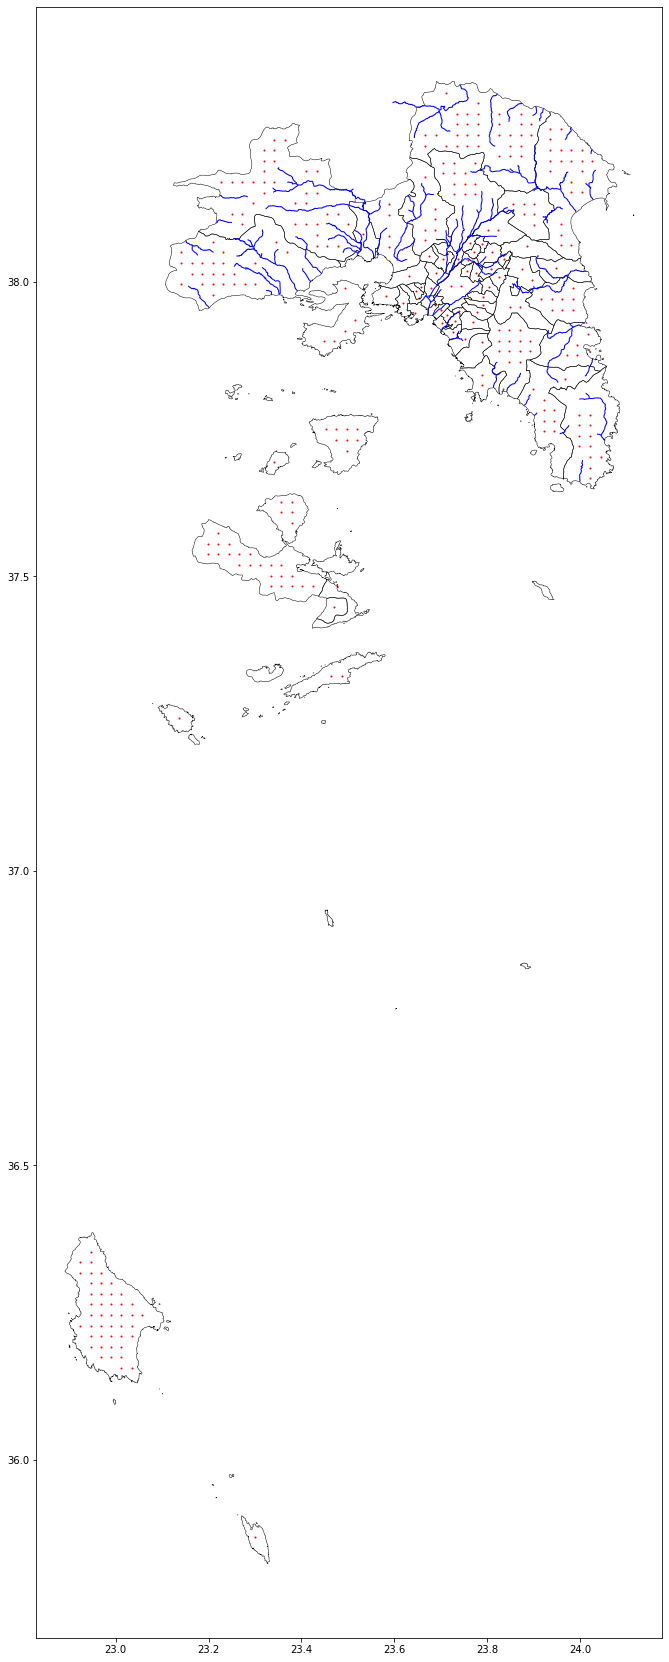

In [33]:
ax = attica_grid_points.plot(markersize=1, figsize=(30, 30), color='red')
attica_gdf.plot(facecolor="none", edgecolor='black', ax=ax, lw=0.5)
attica_rivers_gdf.plot(facecolor="none", edgecolor='blue', ax=ax, lw=1)

In [34]:
value_counts = attica_grid['lau1'].value_counts().sort_values()

In [35]:
arr = value_counts.values

In [36]:
arr_norm = np.ceil((15*(arr - np.min(arr) + 1 )/np.ptp(arr))).astype(int)

In [37]:
value_counts_target = pd.Series(data=arr_norm, index=value_counts.index)

In [38]:
value_counts_target

νικαιας - αγιου ι. ρεντη     1
πορου                        1
πειραιως                     1
περαματος                    1
περιστεριου                  1
                            ..
μεγαρεων                     9
τροιζηνιας                  10
ωρωπου                      11
μανδρας - ειδυλλιας         12
κυθηρων                     16
Length: 66, dtype: int32

In [39]:
idx = []
points = [] 

for index, value in value_counts_target.iteritems():
    if value == value_counts[index]:
        pass
    else: 
        idx.append(index)
        points.append(value_counts[index] - value)
        print(f'Index: {index} || Value: {value_counts[index]} || Target Value: {value}')

Index: βαρης - βουλας - βουλιαγμενης || Value: 2 || Target Value: 1
Index: κηφισιας || Value: 2 || Target Value: 1
Index: παιανιας || Value: 2 || Target Value: 1
Index: αθηναιων || Value: 2 || Target Value: 1
Index: υδρας || Value: 2 || Target Value: 1
Index: παλληνης || Value: 2 || Target Value: 1
Index: ασπροπυργου || Value: 4 || Target Value: 2
Index: μαρκοπουλου μεσογαιας || Value: 4 || Target Value: 2
Index: σαλαμινας || Value: 5 || Target Value: 2
Index: φυλης || Value: 6 || Target Value: 3
Index: διονυσου || Value: 6 || Target Value: 3
Index: αιγινας || Value: 8 || Target Value: 3
Index: σπατων - αρτεμιδος || Value: 8 || Target Value: 3
Index: σαρωνικου || Value: 9 || Target Value: 4
Index: λαυρεωτικης || Value: 12 || Target Value: 5
Index: αχαρνων || Value: 12 || Target Value: 5
Index: κρωπιας || Value: 13 || Target Value: 5
Index: μαραθωνος || Value: 21 || Target Value: 8
Index: μεγαρεων || Value: 24 || Target Value: 9
Index: τροιζηνιας || Value: 28 || Target Value: 10
Index: 

In [40]:
to_remove = pd.Series(data=points, index=idx)

In [41]:
to_remove

βαρης - βουλας - βουλιαγμενης     1
κηφισιας                          1
παιανιας                          1
αθηναιων                          1
υδρας                             1
παλληνης                          1
ασπροπυργου                       2
μαρκοπουλου μεσογαιας             2
σαλαμινας                         3
φυλης                             3
διονυσου                          3
αιγινας                           5
σπατων - αρτεμιδος                5
σαρωνικου                         5
λαυρεωτικης                       7
αχαρνων                           7
κρωπιας                           8
μαραθωνος                        13
μεγαρεων                         15
τροιζηνιας                       18
ωρωπου                           21
μανδρας - ειδυλλιας              22
κυθηρων                          29
dtype: int64

In [42]:
indicies_to_remove = []

for municipality, points in to_remove.iteritems():
    indicies = attica_grid.loc[attica_grid['lau1'] ==  municipality].index.tolist()
    to_removed = random.sample(indicies, points)
    for item in to_removed:
        indicies_to_remove.append(item)

attica_grid.drop(index = indicies_to_remove, axis = 1, inplace = True)
attica_grid.reset_index(inplace = True, drop = True)

In [43]:
attica_grid_points = gpd.GeoDataFrame(attica_grid, geometry=gpd.points_from_xy(attica_grid.x, attica_grid.y))

<AxesSubplot:>

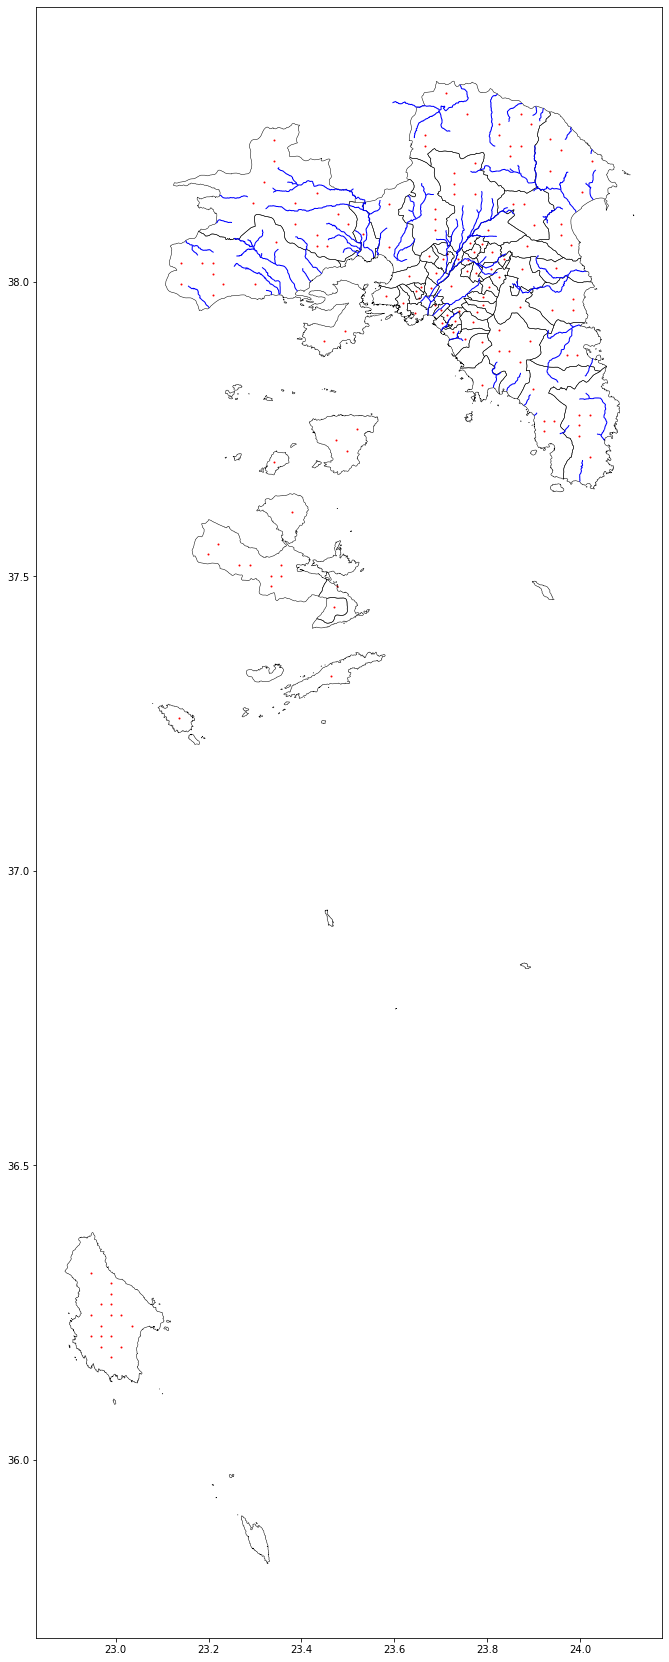

In [44]:
ax = attica_grid_points.plot(markersize=1, figsize=(30, 30), color='red')
attica_gdf.plot(facecolor="none", edgecolor='black', ax=ax, lw=0.5)
attica_rivers_gdf.plot(facecolor="none", edgecolor='blue', ax=ax, lw=1)

In [45]:
len(attica_grid['lau1'].unique())

66

In [46]:
attica_grid

,shape,lau1,x,y,nuts3,geometry
0,"POLYGON ((23.47525 37.32210, 23.47525 37.34006...",υδρας,23.46396,37.33108,αττικης,POINT (23.46396 37.33108)
1,"POLYGON ((23.48588 37.72271, 23.48588 37.74067...",αιγινας,23.47454,37.73169,αττικης,POINT (23.47454 37.73169)
2,"POLYGON ((23.50856 37.70474, 23.50856 37.72271...",αιγινας,23.49722,37.71372,αττικης,POINT (23.49722 37.71372)
3,"POLYGON ((23.53124 37.74067, 23.53124 37.75864...",αιγινας,23.51990,37.74966,αττικης,POINT (23.51990 37.74966)
4,"POLYGON ((23.73276 37.98493, 23.73276 38.00289...",αθηναιων,23.72137,37.99391,αττικης,POINT (23.72137 37.99391)
...,...,...,...,...,...,...
147,"MULTIPOLYGON (((23.46992 37.48999, 23.46989 37...",πορου,23.47721,37.48420,αττικης,POINT (23.47721 37.48420)
148,"POLYGON ((23.72177 38.01826, 23.71958 38.01599...",φιλαδελφειας - χαλκηδονος,23.73834,38.03938,αττικης,POINT (23.73834 38.03938)
149,"POLYGON ((23.78121 38.00972, 23.78145 38.00970...",φιλοθεης - ψυχικου,23.77628,38.01477,αττικης,POINT (23.77628 38.01477)
150,"POLYGON ((23.65604 38.03663, 23.65608 38.03649...",χαϊδαριου,23.63084,38.00942,αττικης,POINT (23.63084 38.00942)


In [47]:
start = start_dt = date(2010, 1, 1)
end = end_dt = date(2021, 12, 31)
delta = timedelta(days=1)

In [48]:
dates = []

while start_dt <= end_dt:
    dates.append(start_dt.isoformat())
    start_dt += delta

In [49]:
print('Dates between', start, 'and', end)
print(dates)

Dates between 2010-01-01 and 2021-12-31
['2010-01-01', '2010-01-02', '2010-01-03', '2010-01-04', '2010-01-05', '2010-01-06', '2010-01-07', '2010-01-08', '2010-01-09', '2010-01-10', '2010-01-11', '2010-01-12', '2010-01-13', '2010-01-14', '2010-01-15', '2010-01-16', '2010-01-17', '2010-01-18', '2010-01-19', '2010-01-20', '2010-01-21', '2010-01-22', '2010-01-23', '2010-01-24', '2010-01-25', '2010-01-26', '2010-01-27', '2010-01-28', '2010-01-29', '2010-01-30', '2010-01-31', '2010-02-01', '2010-02-02', '2010-02-03', '2010-02-04', '2010-02-05', '2010-02-06', '2010-02-07', '2010-02-08', '2010-02-09', '2010-02-10', '2010-02-11', '2010-02-12', '2010-02-13', '2010-02-14', '2010-02-15', '2010-02-16', '2010-02-17', '2010-02-18', '2010-02-19', '2010-02-20', '2010-02-21', '2010-02-22', '2010-02-23', '2010-02-24', '2010-02-25', '2010-02-26', '2010-02-27', '2010-02-28', '2010-03-01', '2010-03-02', '2010-03-03', '2010-03-04', '2010-03-05', '2010-03-06', '2010-03-07', '2010-03-08', '2010-03-09', '2010-0

In [50]:
len(dates)

4383

In [51]:
attica_timeline = pd.DataFrame()

In [52]:
for index, row in attica_grid.iterrows():
    for date in dates:
        attica_timeline = attica_timeline.append({'lau1' : row['lau1'], 
                                                  'region' : row['nuts3'], 
                                                  'x' : row['x'],
                                                  'y' : row['y'],
                                                  'dt_placement': date}, 
                                                  ignore_index = True)

In [53]:
attica_timeline

,lau1,region,x,y,dt_placement
0,υδρας,αττικης,23.46396,37.33108,2010-01-01
1,υδρας,αττικης,23.46396,37.33108,2010-01-02
2,υδρας,αττικης,23.46396,37.33108,2010-01-03
3,υδρας,αττικης,23.46396,37.33108,2010-01-04
4,υδρας,αττικης,23.46396,37.33108,2010-01-05
...,...,...,...,...,...
666211,χαλανδριου,αττικης,23.80941,38.02226,2021-12-27
666212,χαλανδριου,αττικης,23.80941,38.02226,2021-12-28
666213,χαλανδριου,αττικης,23.80941,38.02226,2021-12-29
666214,χαλανδριου,αττικης,23.80941,38.02226,2021-12-30


In [54]:
attica_timeline['dt_placement'] = pd.to_datetime(attica_timeline['dt_placement'])

In [55]:
attica_timeline.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 666216 entries, 0 to 666215
Data columns (total 5 columns):
 #   Column        Non-Null Count   Dtype         
---  ------        --------------   -----         
 0   lau1          666216 non-null  object        
 1   region        666216 non-null  object        
 2   x             666216 non-null  float64       
 3   y             666216 non-null  float64       
 4   dt_placement  666216 non-null  datetime64[ns]
dtypes: datetime64[ns](1), float64(2), object(2)
memory usage: 25.4+ MB


In [56]:
attica_timeline.to_csv('data/GR_Attica_Spatiotemporal_Timeline_2010-2021.csv', index = False)

In [57]:
attica_timeline

,lau1,region,x,y,dt_placement
0,υδρας,αττικης,23.46396,37.33108,2010-01-01
1,υδρας,αττικης,23.46396,37.33108,2010-01-02
2,υδρας,αττικης,23.46396,37.33108,2010-01-03
3,υδρας,αττικης,23.46396,37.33108,2010-01-04
4,υδρας,αττικης,23.46396,37.33108,2010-01-05
...,...,...,...,...,...
666211,χαλανδριου,αττικης,23.80941,38.02226,2021-12-27
666212,χαλανδριου,αττικης,23.80941,38.02226,2021-12-28
666213,χαλανδριου,αττικης,23.80941,38.02226,2021-12-29
666214,χαλανδριου,αττικης,23.80941,38.02226,2021-12-30


In [58]:
attica_timeline['dt_placement'].iloc[15].day

16

In [59]:
attica_timeline_biweekly = attica_timeline.copy()
remove = []

for index, row in attica_timeline.iterrows():
    if row['dt_placement'].day == 1 or row['dt_placement'].day == 16:
        pass
    else:
        remove.append(index)


attica_timeline_biweekly.drop(index = remove, axis = 1, inplace = True)
attica_timeline_biweekly.reset_index(inplace = True, drop = True)

In [60]:
attica_timeline_biweekly.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 43776 entries, 0 to 43775
Data columns (total 5 columns):
 #   Column        Non-Null Count  Dtype         
---  ------        --------------  -----         
 0   lau1          43776 non-null  object        
 1   region        43776 non-null  object        
 2   x             43776 non-null  float64       
 3   y             43776 non-null  float64       
 4   dt_placement  43776 non-null  datetime64[ns]
dtypes: datetime64[ns](1), float64(2), object(2)
memory usage: 1.7+ MB


In [61]:
attica_timeline_biweekly.to_csv('data/GR_Attica_Spatiotemporal_Timeline_Biweekly_2010-2021.csv', index = False)